# 01 — Figure 1: Cell-type-specific instability and tail sensitivity of the CPA severity metric

Reproduces Figure 1 of the manuscript (three-panel single-row composite) from the n=100 CPA evidence base.

**Manuscript reference:** Figure 1; Results §3.1, §3.2, §3.3.

**Panels:**
- **A** — Per-seed severity Pearson at n=100, four conditions (instability).
- **B** — LOO mechanism signature: LOO_max vs top-1 driver concentration (400 points).
- **C** — Winsorisation effect on spread (raw vs winsorised range per condition).

**Visual encoding** (consistent across all panels):
- Cell type colour: K562 = blue, RPE1 = orange.
- Split type marker: random = circle, stratified = square.
- Raw vs winsorised: solid fill vs hatched (Panel C only).

**Sources:**
- `precomputed/eval/diag_loo_sensitivity_n100.csv` (Panels A, B; filtered to `model_id == "CPA"`).
- `precomputed/eval/diag_winsorise_n100_summary.csv` (Panel C).

**Outputs:**
- `figs/figure1_methodology.png` (300 DPI raster)
- `figs/figure1_methodology.pdf` (vector)
- `precomputed/figure_inputs/figure1_panel_summary.csv` (per-condition values plotted)


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Make repo-root style module importable
sys.path.insert(0, str(Path.cwd()))
from perturb_style import K562_COLOR, RPE1_COLOR, FIG_MAIN, FIGS_DIR, PRECOMPUTED_DIR


## Load data and verify shapes

In [2]:
LOO_CSV = PRECOMPUTED_DIR / "eval" / "diag_loo_sensitivity_n100.csv"
WINS_CSV = PRECOMPUTED_DIR / "eval" / "diag_winsorise_n100_summary.csv"

cpa = pd.read_csv(LOO_CSV)
cpa = cpa[cpa.model_id == "CPA"].copy()
wins = pd.read_csv(WINS_CSV)

print(f"CPA rows: {len(cpa)} (expected 400 = 4 conditions x 100 seeds)")
print(cpa.groupby(["cell_type", "split_type"]).size().to_string())
print(f"\nWinsorisation summary rows: {len(wins)} (expected 4)")
print(wins[["condition", "raw_range", "wins_range", "range_pct_change"]].to_string(index=False))


CPA rows: 400 (expected 400 = 4 conditions x 100 seeds)
cell_type  split_type
K562       random        100
           stratified    100
RPE1       random        100
           stratified    100

Winsorisation summary rows: 4 (expected 4)
      condition  raw_range  wins_range  range_pct_change
    K562 random     1.0943      0.8494             -22.4
K562 stratified     1.1840      0.9941             -16.0
    RPE1 random     0.7552      0.7865               4.1
RPE1 stratified     0.8557      0.8985               5.0


## Plot constants and panel renderers

Three rendering functions, one per panel. Condition order, axis ranges, and styling are fixed to match the manuscript figure.

In [3]:
CONDITIONS = [
    ("K562\nrand", "K562", "random"),
    ("K562\nstrat", "K562", "stratified"),
    ("RPE1\nrand", "RPE1", "random"),
    ("RPE1\nstrat", "RPE1", "stratified"),
]
XLABELS = [c[0] for c in CONDITIONS]
WINS_ORDER = ["K562 random", "K562 stratified", "RPE1 random", "RPE1 stratified"]
PANEL_TITLES = {"A": "Per-seed instability", "B": "LOO mechanism", "C": "Winsorisation effect"}
MEDIAN_EDGE = "black"
REF_COLOR = "#999999"

def _color(cell):
    return K562_COLOR if cell == "K562" else RPE1_COLOR

def _marker(split):
    return "o" if split == "random" else "s"

def _mad(x):
    x = np.asarray(x, float)
    return float(np.median(np.abs(x - np.median(x))))

def render_panel_a(ax, cpa_df):
    """Per-seed severity Pearson strip plot, four conditions, n=100 each."""
    rng = np.random.default_rng(0)
    summary = []
    for i, (label, cell, split) in enumerate(CONDITIONS):
        sub = cpa_df[(cpa_df.cell_type == cell) & (cpa_df.split_type == split)]
        vals = sub.severity_pearson_raw.values.astype(float)
        xs = i + (rng.random(len(vals)) - 0.5) * 0.32
        color, mk = _color(cell), _marker(split)
        ax.scatter(xs, vals, s=9, marker=mk, c=color, alpha=0.30,
                   edgecolors="none", zorder=2)
        med, mad = float(np.median(vals)), _mad(vals)
        ax.vlines(i, med - mad, med + mad, colors=MEDIAN_EDGE, linewidth=1.1, zorder=4)
        ax.hlines([med - mad, med + mad], i - 0.07, i + 0.07,
                  colors=MEDIAN_EDGE, linewidth=1.1, zorder=4)
        ax.scatter([i], [med], s=72, marker=mk, c=color, edgecolors=MEDIAN_EDGE,
                   linewidths=1.2, zorder=5)
        nflip = int((vals < 0).sum())
        ax.text(i, -0.045, f"{nflip}/100", ha="center", va="top", fontsize=6.5,
                color="#222222", zorder=6,
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75))
        summary.append(dict(condition=f"{cell} {split}", median=med, mad=mad,
                            sign_flips=nflip, raw_range=float(vals.max() - vals.min())))
    ax.axhline(0, color=REF_COLOR, linewidth=0.7, zorder=1)
    ax.set_xticks(range(4))
    ax.set_xticklabels(XLABELS, fontsize=7)
    ax.set_ylabel("severity Pearson", fontsize=8)
    ax.set_xlim(-0.55, 3.55)
    ax.set_ylim(-0.68, 0.72)
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    ax.tick_params(labelsize=7)
    return summary

def render_panel_b(ax, cpa_df):
    """LOO_max vs top-1 driver concentration scatter, 400 points + medians."""
    ax.axvline(0.15, color=REF_COLOR, linestyle="--", linewidth=0.7, zorder=1)
    ax.axhline(0.5, color=REF_COLOR, linestyle="--", linewidth=0.7, zorder=1)
    for cell in ("K562", "RPE1"):
        for split in ("random", "stratified"):
            sub = cpa_df[(cpa_df.cell_type == cell) & (cpa_df.split_type == split)]
            ax.scatter(sub.LOO_max_abs_delta, sub.top1_fraction, s=11,
                       marker=_marker(split), c=_color(cell), alpha=0.25,
                       edgecolors="none", zorder=2)
    for cell in ("K562", "RPE1"):
        for split in ("random", "stratified"):
            sub = cpa_df[(cpa_df.cell_type == cell) & (cpa_df.split_type == split)]
            xm = float(np.median(sub.LOO_max_abs_delta))
            ym = float(np.median(sub.top1_fraction))
            ax.scatter([xm], [ym], s=88, marker=_marker(split), c=_color(cell),
                       edgecolors="black", linewidths=1.2, alpha=1.0, zorder=5)
    ax.set_xlabel(r"LOO$_{\max}$ (max |$\Delta$r|, leave-one-out)", fontsize=8)
    ax.set_ylabel(r"$\tau_1$ (top-1 driver concentration)", fontsize=8)
    ax.set_xlim(0, 0.62)
    ax.set_ylim(0.30, 0.86)
    ax.grid(linestyle=":", alpha=0.35)
    ax.tick_params(labelsize=7)
    handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=K562_COLOR,
               markeredgecolor=K562_COLOR, markersize=5, label="K562 rand"),
        Line2D([0], [0], marker="s", linestyle="none", markerfacecolor=K562_COLOR,
               markeredgecolor=K562_COLOR, markersize=5, label="K562 strat"),
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=RPE1_COLOR,
               markeredgecolor=RPE1_COLOR, markersize=5, label="RPE1 rand"),
        Line2D([0], [0], marker="s", linestyle="none", markerfacecolor=RPE1_COLOR,
               markeredgecolor=RPE1_COLOR, markersize=5, label="RPE1 strat"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=6, frameon=False,
              handletextpad=0.3, labelspacing=0.22, borderpad=0.2)


def render_panel_c(ax, wins_df):
    """Raw vs winsorised range per condition (paired bars), with % change."""
    w = 0.38
    for i, cond in enumerate(WINS_ORDER):
        row = wins_df[wins_df.condition == cond].iloc[0]
        cell = "K562" if cond.startswith("K562") else "RPE1"
        color = _color(cell)
        rr, wr = float(row.raw_range), float(row.wins_range)
        ax.bar(i - w / 2, rr, width=w, color=color, alpha=0.9,
               edgecolor=color, linewidth=0.8, zorder=3)
        ax.bar(i + w / 2, wr, width=w, facecolor="white", edgecolor=color,
               hatch="////", linewidth=0.8, zorder=3)
        pct = float(row.range_pct_change)
        sign = "-" if pct < 0 else "+"
        ax.text(i, max(rr, wr) + 0.04, f"{sign}{abs(pct):.0f}%", ha="center",
                va="bottom", fontsize=7, color="black")
    ax.axvline(1.5, color=REF_COLOR, linestyle=":", linewidth=0.6, alpha=0.7, zorder=1)
    ax.set_xticks(range(4))
    ax.set_xticklabels(XLABELS, fontsize=7)
    ax.set_ylabel("range of severity Pearson", fontsize=8)
    ax.set_xlim(-0.6, 3.6)
    ax.set_ylim(0, 1.5)
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    ax.tick_params(labelsize=7)
    handles = [
        Patch(facecolor="0.45", edgecolor="0.45", label="unwinsorised"),
        Patch(facecolor="white", edgecolor="0.45", hatch="////", label="winsorised"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=6.5, frameon=False,
              handlelength=1.3, handleheight=1.1, borderpad=0.2, labelspacing=0.25)

## Compose figure and save

Saved: figs/figure1_methodology.png
Saved: figs/figure1_methodology.pdf
Saved: precomputed/figure_inputs/figure1_panel_summary.csv


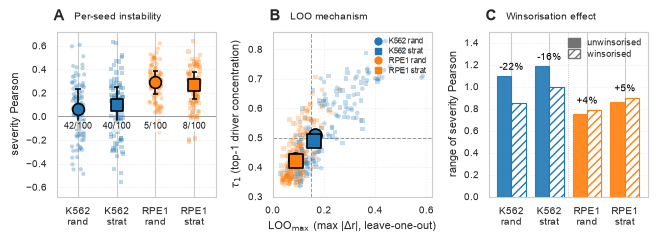

In [4]:
plt.rcParams.update({"font.family": "sans-serif", "font.size": 8})
fig, axes = plt.subplots(1, 3, figsize=FIG_MAIN)
panel_a_summary = render_panel_a(axes[0], cpa)
render_panel_b(axes[1], cpa)
render_panel_c(axes[2], wins)

for ax, letter in zip(axes, "ABC"):
    ax.text(-0.02, 1.05, letter, transform=ax.transAxes, fontsize=10.5,
            fontweight="bold", va="bottom", ha="left")
    ax.text(0.11, 1.06, PANEL_TITLES[letter], transform=ax.transAxes,
            fontsize=7.5, va="bottom", ha="left", color="#222222")

fig.subplots_adjust(left=0.078, right=0.987, top=0.86, bottom=0.20, wspace=0.36)

FIGS_DIR.mkdir(exist_ok=True)
png_path = FIGS_DIR / "figure1_methodology.png"
pdf_path = FIGS_DIR / "figure1_methodology.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

# Audit export of the per-condition plotted values
audit_dir = PRECOMPUTED_DIR / "figure_inputs"
audit_dir.mkdir(exist_ok=True, parents=True)
sa = pd.DataFrame(panel_a_summary)
sb = wins[["condition", "raw_range", "wins_range", "range_pct_change",
           "raw_MAD", "wins_MAD", "raw_p5_p95_width", "wins_p5_p95_width"]].copy()
audit = sa.merge(sb, on="condition", how="left")
audit.to_csv(audit_dir / "figure1_panel_summary.csv", index=False)

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {audit_dir / 'figure1_panel_summary.csv'}")
plt.show()


## Bootstrap 95% CIs on the mean severity Pearson

For each of the four CPA n=100 conditions, compute a bootstrap 95% confidence interval on the mean severity Pearson via 10,000 resamples with replacement. These CIs are quoted in Results §3.1 of the manuscript. Saved to `precomputed/figure_inputs/bootstrap_ci_summary.csv` so the values are emitted from a notebook rather than only documented in the manuscript text.

**Manuscript reference:** Results §3.1 (bootstrap 95% confidence interval on the mean for each condition).

In [5]:
def bootstrap_ci_mean(x, n_resamples=10_000, ci=0.95, seed=0):
    """Bootstrap percentile CI on the mean of x."""
    rng = np.random.default_rng(seed)
    n = len(x)
    boots = np.empty(n_resamples)
    for i in range(n_resamples):
        boots[i] = float(rng.choice(x, size=n, replace=True).mean())
    alpha = (1 - ci) / 2
    return float(np.percentile(boots, 100 * alpha)), float(np.percentile(boots, 100 * (1 - alpha)))

boot_rows = []
for label, cell, split in CONDITIONS:
    sub = cpa[(cpa.cell_type == cell) & (cpa.split_type == split)]
    vals = sub.severity_pearson_raw.values.astype(float)
    lo, hi = bootstrap_ci_mean(vals, n_resamples=10_000, ci=0.95, seed=0)
    boot_rows.append({
        "condition": f"{cell} {split}",
        "n": int(len(vals)),
        "mean": round(float(np.mean(vals)), 4),
        "ci95_low": round(lo, 4),
        "ci95_high": round(hi, 4),
    })

bootstrap_summary = pd.DataFrame(boot_rows)
boot_path = PRECOMPUTED_DIR / "figure_inputs" / "bootstrap_ci_summary.csv"
bootstrap_summary.to_csv(boot_path, index=False)

print(f"Saved: {boot_path}")
print()
print(bootstrap_summary.to_string(index=False))


Saved: precomputed/figure_inputs/bootstrap_ci_summary.csv

      condition   n   mean  ci95_low  ci95_high
    K562 random 100 0.0430   -0.0041     0.0893
K562 stratified 100 0.0657    0.0193     0.1125
    RPE1 random 100 0.2694    0.2383     0.3003
RPE1 stratified 100 0.2412    0.2087     0.2728
